# 5장 1강: 시퀀스-투-시퀀스 구조의 이해
## 3. PyTorch를 활용한 LSTM 기반 영-한 단어 번역 실습

### 3.1 인코더(Encoder) 구현

In [ ]:
# 수업 시간 코딩 : 
import torch
import torch.nn as nn

# 인코더(Encoder) 클래스 정의
class EncoderLSTM(nn.Module):
    # 어떤 레이어를 쓸지 준비
    def __init__(self, input_size, embed_size, hidden_size):
        super().__init__()

        # 임베딩 레이어 : 
        # 입력 단어 인덱스를 고정된 차원의 밀집 벡터로 변환하는 레이어
        self.embedding = nn.Embedding(input_size, embed_size)
        
        #LSTM 레이어 : 
        # 단기/장기 기억을 순차적으로 업데이트하는 LSTM 레이어
        # batch_first=True : 미니 배치
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

    # 순방향 전파 :    
    # 실제 데이터가 들어왔을 때 그 레이어들을 어떤 순서로 통과시킬지 정의  
    def forward(self, x):
        embedded = self.embedding(x)  # 형태: (batch, seq_len, embed_size)
        outputs, (hidden, cell) = self.lstm(embedded) # hidden, cell > 컨텍스트 벡터
        # 마지막 시점의 은닉 상태와 셀 상태(컨텍스트 벡터)를 반환합니다.
        return hidden, cell

In [ ]:
# 교안 코딩 : 
import torch
import torch.nn as nn

# 인코더(Encoder) 클래스 정의
class EncoderLSTM(nn.Module):
    
    # 어떤 레이어를 쓸지 준비
    def __init__(self, input_size, embed_size, hidden_size):
        super(EncoderLSTM, self).__init__()                    ### <<<<<<교안/수업 코딩 차이 / 여기가 다름!!!!!!

        # 임베딩 레이어 : 
        # 입력 단어 인덱스를 고정된 차원의 밀집 벡터로 변환하는 레이어
        self.embedding = nn.Embedding(input_size, embed_size)

        #LSTM 레이어 : 
        # 단기/장기 기억을 순차적으로 업데이트하는 LSTM 레이어
        # batch_first=True : 미니 배치
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

    # 순방향 전파 :    
    # 실제 데이터가 들어왔을 때 그 레이어들을 어떤 순서로 통과시킬지 정의  
    def forward(self, x):
        embedded = self.embedding(x)  # 형태: (batch, seq_len, embed_size)
        outputs, (hidden, cell) = self.lstm(embedded)
        # 마지막 시점의 은닉 상태와 셀 상태(컨텍스트 벡터)를 반환합니다.
        return hidden, cell

### 3.2 디코더(Decoder) 구현

In [ ]:
# 수업 시간 코딩 : 

# 디코더(Decoder) 클래스 정의
class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size):
        super().__init__()                                      ### <<<<<<교안/수업 코딩 차이 / 여기가 다름!!!!!!

        # 임베딩 레이어 : 
        # 타깃 단어 인덱스를 밀집 벡터로 변환하는 레이어
        self.embedding = nn.Embedding(output_size, embed_size)

        # LSTM 레이어:
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

        # 출력층(분류기):
        # LSTM 출력값(hidden)을 바탕으로 최종 단어별 점수를 계산하는 선형 레이어
        self.output = nn.Linear(hidden_size, output_size)          ### <<<<<<교안/수업 코딩 차이 / 여기가 다름!!!!!!

        # hidden_state > 초기값은 인코더의 컨텍스트 벡터!!!!! / 디코더 초기값 설정
    def forward(self, x, hidden_state):
        # hidden_state 매개변수에는 (hidden, cell) 튜플이 주입됩니다.
        embedded = self.embedding(x)  # 형태: (batch, seq_len, embed_size)
        outputs, (hidden, cell) = self.lstm(embedded, hidden_state)
        # 단일 시점 예측을 위해 차원을 조정한 후 선형 레이어를 통과시킵니다.
        # 예측 결과:
        prediction = self.output(outputs.squeeze(1))  # 형태: (batch, output_size) 3차원->2차원    ### <<<<<<교안/수업 코딩 차이 / 여기가 다름!!!!!!
        return prediction, (hidden, cell)

In [ ]:
# 교안 코딩 : 
# 디코더(Decoder) 클래스 정의
class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size):
        super(DecoderLSTM, self).__init__()
        # 타깃 단어 인덱스를 밀집 벡터로 변환하는 레이어
        self.embedding = nn.Embedding(output_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        # LSTM 출력값(hidden)을 바탕으로 최종 단어별 점수를 계산하는 선형 레이어
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x, hidden_state):
        # hidden_state 매개변수에는 (hidden, cell) 튜플이 주입됩니다.
        embedded = self.embedding(x)  # 형태: (batch, seq_len, embed_size)
        output, (hidden, cell) = self.lstm(embedded, hidden_state)
        # 단일 시점 예측을 위해 차원을 조정한 후 선형 레이어를 통과시킵니다.
        prediction = self.fc(output.squeeze(1))  # 형태: (batch, output_size)
        return prediction, (hidden, cell)

### 3.3 모델 완성 및 테스트 (데이터 전처리, 학습, 추론)

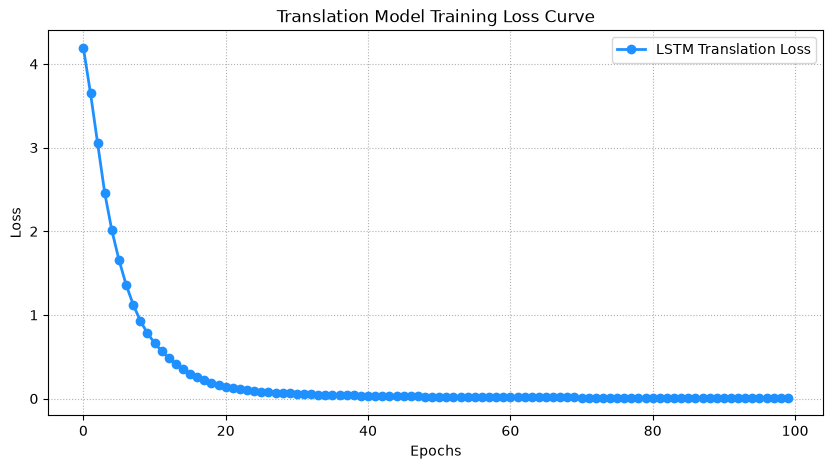


--- [추론 테스트] 번역 결과 확인 ---
입력(ENG): hello   ===>  출력(KOR): 안녕
입력(ENG): car     ===>  출력(KOR): 차
입력(ENG): cat     ===>  출력(KOR): 고양이
입력(ENG): dog     ===>  출력(KOR): 개
입력(ENG): sun     ===>  출력(KOR): 태양


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim

# ==========================================
# 데이터 준비 및 어휘 사전(Vocabulary) 구축
# ==========================================
pairs = [
    ("hello", "안녕"),
    ("car", "차"),
    ("cat", "고양이"),
    ("dog", "개"),
    ("sun", "태양")
]

# 특수 토큰 설정 (<pad>: 패딩, <sos>: 시작 신호, <eos>: 종료 신호) /// <pad> : 문장 길이 맞추기 위한 빈칸
# Padding = 짧은 문장의 남는 자리를 <pad>로 채워서 길이를 맞추는 것
src_words = ["<pad>"] + list(sorted(list(set([p[0] for p in pairs])))) # 타겟 부분
tgt_words = ["<pad>", "<sos>", "<eos>"] + list(sorted(list(set([p[1] for p in pairs])))) # 번역될 부분

# 인덱스 변환 맵 생성
# w2i는 단어를 숫자로, i2w는 숫자를 다시 단어로 바꾸기 위한 사전이고, 그 숫자 인덱스를 Embedding에 넣어서 실제 벡터로 변환한다.
# i2w는 임베딩 전에 쓰는 게 아니라, 모델 출력 숫자를 다시 단어로 해석할 때 쓰려고 미리 만들어두는 변환표
src_w2i = {w: i for i, w in enumerate(src_words)} # word to index # source, 입력 언어
src_i2w = {i: w for i, w in enumerate(src_words)} # index to word
tgt_w2i = {w: i for i, w in enumerate(tgt_words)} # word to index # target, 출력 언어
tgt_i2w = {i: w for i, w in enumerate(tgt_words)} # index to word

def encode_src(sent): return [src_w2i[sent]]
def encode_tgt(sent): return [tgt_w2i["<sos>"]] + [tgt_w2i[sent]] + [tgt_w2i["<eos>"]]


embed_size = 16
hidden_size = 16

# 모델 선언 및 지정된 디바이스로 할당
encoder = EncoderLSTM(len(src_words), embed_size, hidden_size)
decoder = DecoderLSTM(len(tgt_words), embed_size, hidden_size)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.01)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 텐서 데이터 변환 후 가속 디바이스로 연동
src_tensors = [torch.tensor([encode_src(p[0])], dtype=torch.long) for p in pairs]
tgt_tensors = [torch.tensor([encode_tgt(p[1])], dtype=torch.long) for p in pairs]

# ==========================================
# 모델 학습 루프 실행 (교사 강요 기법 적용)
# ==========================================
losses = []

for epoch in range(100):
    epoch_loss = 0
    for src_t, tgt_t in zip(src_tensors, tgt_tensors): # src_tensors /인코더 ///  tgt_tensors/디코더
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        # [인코더] 컨텍스트 벡터 추출
        enc_hidden, enc_cell = encoder(src_t)
        
        # [디코더] 초기 상태를 인코더의 출력값으로 연동
        decoder_hidden_state = (enc_hidden, enc_cell)
        decoder_input = tgt_t[:, 0:1]  # 첫 시작 단어는 <sos> 토큰
        
        loss = 0
        for t in range(1, tgt_t.size(1)):
            prediction, decoder_hidden_state = decoder(decoder_input, decoder_hidden_state)
            target = tgt_t[:, t]
            loss += criterion(prediction, target)
            
            # [교사 강요] 모델의 예측값 대신 실제 정답 데이터를 다음 시점의 입력으로 강제 설정
            decoder_input = tgt_t[:, t:t+1]
            
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
        
        epoch_loss += loss.item()
        
    losses.append(epoch_loss / len(pairs))

# ==========================================
# 학습 오차(Loss) 하강 곡선 시각화
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(losses, color='dodgerblue', linewidth=2, linestyle='-', marker='o', label='LSTM Translation Loss')
plt.title('Translation Model Training Loss Curve', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

# ==========================================
# 모델 추론 및 번역 성능 최종 테스트
# ==========================================
print("\n--- [추론 테스트] 번역 결과 확인 ---")
with torch.no_grad():
    for src_t, p in zip(src_tensors, pairs):
        enc_hidden, enc_cell = encoder(src_t)
        decoder_hidden_state = (enc_hidden, enc_cell)
        
        # 입력용 시작 토큰 생성 및 디바이스 연동
        decoder_input = torch.tensor([[tgt_w2i["<sos>"]]], dtype=torch.long)
        translated_sentence = []
        
        for _ in range(5):  # 출력 최대 길이 제한
            prediction, decoder_hidden_state = decoder(decoder_input, decoder_hidden_state)
            predicted_idx = prediction.argmax(1).item()  # 최고 점수를 얻은 토큰 인덱스 선택
            
            if predicted_idx == tgt_w2i["<eos>"]:
                break
                
            translated_sentence.append(tgt_i2w[predicted_idx])
            
            # 자가 예측(기본 추론): 모델이 직접 예측한 단어를 다음 시점의 입력값 및 디바이스 설정으로 갱신
            decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long)
            
        print(f"입력(ENG): {p[0]:6s}  ===>  출력(KOR): {' '.join(translated_sentence)}")